# **Project Name**    -  Flipkart Customer Service Satisfaction (CSAT) Classification

##### **Project Type**    - Classification
##### **Contribution**    - Individual
##### **Author**    - Varshith Kandikatla

# **Project Summary -**

Flipkart, one of India's largest e-commerce platforms, depends on high-quality customer service to retain customers in a fiercely competitive market. This project analyses **85,907 customer-support interactions** to understand what drives the **Customer Satisfaction (CSAT) score** and to build a machine-learning model that predicts whether an interaction will leave the customer **satisfied or dissatisfied**.

The raw CSAT score is recorded on a 1–5 scale, but it is **heavily imbalanced** — about 69% of all interactions score a 5, while scores of 2 and 3 are rare. Because CSAT is reported in practice as the *percentage of satisfied customers*, we reframe the target as a **binary classification problem**: an interaction is **Satisfied (1)** when the CSAT score is 4 or 5, and **Dissatisfied (0)** when it is 1, 2, or 3. This framing is more business-relevant, more statistically tractable, and lets us focus the model on the question managers actually care about: *which interactions risk an unhappy customer?*

The workflow follows a complete ML pipeline. In **EDA**, we explore satisfaction across channels, issue categories, agent shifts, agent tenure, and time of day, and engineer the single most important feature — **response time** (minutes between an issue being reported and answered). Visual analysis reveals that dissatisfied customers wait a **median of 19 minutes versus just 5 minutes** for satisfied ones, that the **Email channel** underperforms phone channels, and that **agents still in on-the-job training** produce the lowest satisfaction.

After cleaning (dropping columns with 80–99% missing values, fixing invalid negative response times, and imputing the rest), we **encode categorical variables**, **scale numeric features**, and address the **class imbalance** using balanced class weights. We then train and compare **three models — Logistic Regression, Decision Tree, and Random Forest** — and tune the best with **GridSearchCV cross-validation**.

The **Random Forest** is the strongest model, reaching roughly **0.80 F1, 0.87 precision, and 0.67 ROC-AUC** on the held-out test set. Its feature-importance analysis confirms the EDA story: **response time accounts for over half of the model's predictive power**, with hour-of-day and whether the customer left written remarks next.

The clear business takeaway is that **speed of response is the dominant, controllable lever** for customer satisfaction. Flipkart can improve CSAT most by reducing response latency — especially on the slower Email channel and during high-volume hours — and by accelerating the ramp-up of agents in training. The model can be deployed to flag at-risk interactions in real time so supervisors can intervene before a customer becomes dissatisfied.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**

**Predict whether a Flipkart customer-support interaction will result in a satisfied or dissatisfied customer (binary CSAT classification), and identify the key drivers of satisfaction so that the business can prioritise improvements to its support operations.**

#### **Define Your Business Objective?**

The objective is two-fold: (1) **understand the drivers of customer satisfaction** across channels, categories, agents, and timing so management can target improvements, and (2) **build a predictive model** that flags interactions likely to end in dissatisfaction, enabling proactive intervention. Success means higher overall CSAT, faster issue resolution, and better-targeted agent training — all of which support customer retention and brand loyalty.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Data handling
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats

# Machine learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, RocCurveDisplay)

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

### Dataset Loading

In [2]:
# Load the customer support dataset
df = pd.read_csv('Customer_support_data.csv')

### Dataset First View

In [3]:
# Preview the first few rows
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


### Dataset Rows & Columns count

In [4]:
print(f"Number of rows   : {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows   : 85907
Number of columns: 20


### Dataset Information

In [5]:
# Data types and non-null counts for every column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  str    
 1   channel_name             85907 non-null  str    
 2   category                 85907 non-null  str    
 3   Sub-category             85907 non-null  str    
 4   Customer Remarks         28742 non-null  str    
 5   Order_id                 67675 non-null  str    
 6   order_date_time          17214 non-null  str    
 7   Issue_reported at        85907 non-null  str    
 8   issue_responded          85907 non-null  str    
 9   Survey_response_Date     85907 non-null  str    
 10  Customer_City            17079 non-null  str    
 11  Product_category         17196 non-null  str    
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name               85907 no

#### Duplicate Values

In [6]:
# Count fully duplicated rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


#### Missing Values/Null Values

In [7]:
# Missing values per column, as a count and as a percentage
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().mean()*100).round(1)
})
missing[missing['missing_count'] > 0].sort_values('missing_pct', ascending=False)

,missing_count,missing_pct
connected_handling_time,85665,99.7
Customer_City,68828,80.1
order_date_time,68693,80.0
Product_category,68711,80.0
Item_price,68701,80.0
Customer Remarks,57165,66.5
Order_id,18232,21.2


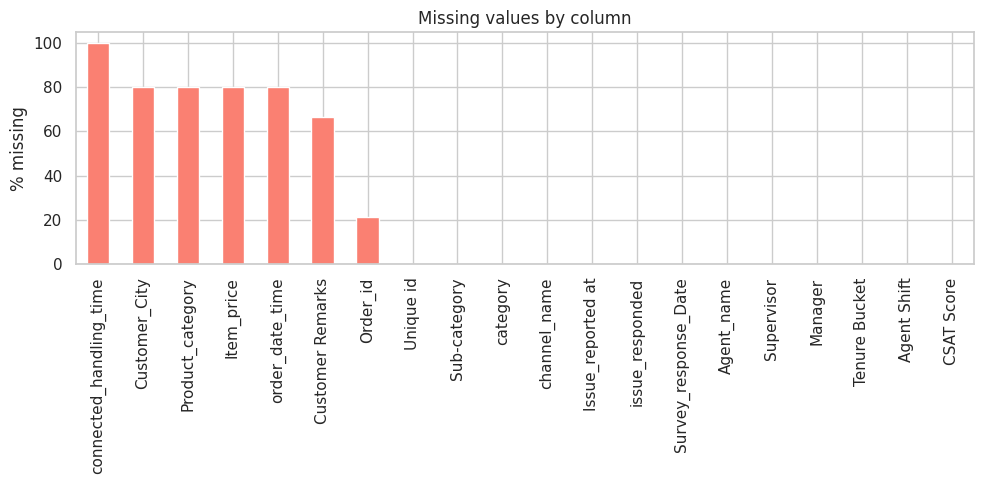

In [8]:
# Visualise missingness across columns
plt.figure(figsize=(10,5))
(df.isnull().mean()*100).sort_values(ascending=False).plot(kind='bar', color='salmon')
plt.ylabel('% missing'); plt.title('Missing values by column'); plt.tight_layout(); plt.show()

### What did you know about your dataset?

The dataset has **85,907 rows and 20 columns** describing individual customer-support interactions at Flipkart. The target is **CSAT Score (1–5)**. There are **no duplicate rows**. However, missingness is severe and uneven:

- `connected_handling_time` is **~99.7% missing** (essentially unusable),
- `Customer_City`, `Product_category`, `Item_price`, and `order_date_time` are each **~80% missing**,
- `Customer Remarks` is **~66% missing** (most customers leave no written feedback),
- `Order_id` is **~21% missing**.

Identifier columns (`Unique id`, `Order_id`) carry no predictive value, and `Agent_name` has very high cardinality (~1,300 agents). The useful, well-populated signal lives in the **channel, category, agent shift, tenure bucket, and the two timestamps** (issue reported / responded), from which we can engineer a response-time feature.

## ***2. Understanding Your Variables***

### Variables Description

In [9]:
# Statistical summary of numeric columns
df.describe()

,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


**Key variables:**
- **CSAT Score** — target; customer satisfaction on a 1–5 scale.
- **channel_name** — support channel (Inbound, Outcall, Email).
- **category / Sub-category** — type of issue raised.
- **Issue_reported at / issue_responded** — timestamps used to derive response time.
- **Tenure Bucket / Agent Shift / Supervisor / Manager** — agent and team attributes.
- **Customer Remarks** — free-text feedback (mostly missing).
- **Item_price, Customer_City, Product_category** — order attributes (mostly missing).

### Check Unique Values for each variable.

In [10]:
# Number of unique values per column
df.nunique().sort_values(ascending=False)

Unique id                  85907
Order_id                   67675
Issue_reported at          30923
issue_responded            30262
Customer Remarks           18231
order_date_time            13766
Item_price                  2789
Customer_City               1782
Agent_name                  1371
connected_handling_time      211
Sub-category                  57
Supervisor                    40
Survey_response_Date          31
category                      12
Product_category               9
Manager                        6
Agent Shift                    5
Tenure Bucket                  5
CSAT Score                     5
channel_name                   3
dtype: int64

In [11]:
# Inspect the categories of the main low-cardinality features
for col in ['channel_name', 'Agent Shift', 'Tenure Bucket', 'CSAT Score']:
    print(f"{col}: {sorted(df[col].dropna().unique().tolist())}")

channel_name: ['Email', 'Inbound', 'Outcall']
Agent Shift: ['Afternoon', 'Evening', 'Morning', 'Night', 'Split']
Tenure Bucket: ['0-30', '31-60', '61-90', '>90', 'On Job Training']
CSAT Score: [1, 2, 3, 4, 5]


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# ---- 1. Create the BINARY target: Satisfied (CSAT 4-5) vs Dissatisfied (CSAT 1-3) ----
df['Satisfied'] = (df['CSAT Score'] >= 4).astype(int)

# ---- 2. Parse the two timestamps and engineer response time (minutes) ----
df['Issue_reported at'] = pd.to_datetime(df['Issue_reported at'], format='%d/%m/%Y %H:%M', errors='coerce')
df['issue_responded']  = pd.to_datetime(df['issue_responded'],  format='%d/%m/%Y %H:%M', errors='coerce')
df['response_mins'] = (df['issue_responded'] - df['Issue_reported at']).dt.total_seconds() / 60

# ---- 3. Fix invalid (negative) response times -> treat as missing ----
n_neg = (df['response_mins'] < 0).sum()
print(f"Invalid negative response times set to NaN: {n_neg}")
df.loc[df['response_mins'] < 0, 'response_mins'] = np.nan

# ---- 4. Time-of-day features from the report timestamp ----
df['report_hour'] = df['Issue_reported at'].dt.hour
df['report_dow']  = df['Issue_reported at'].dt.dayofweek

# ---- 5. Flag for whether the customer left written remarks ----
df['has_remarks'] = df['Customer Remarks'].notna().astype(int)

df[['CSAT Score','Satisfied','response_mins','report_hour','has_remarks']].head()

Invalid negative response times set to NaN: 3128


,CSAT Score,Satisfied,response_mins,report_hour,has_remarks
0,5,1,34.0,11,0
1,5,1,2.0,12,0
2,5,1,22.0,20,0
3,5,1,20.0,20,0
4,5,1,2.0,10,0


### What all manipulations have you done and insights you found?

**Manipulations:**
1. **Created a binary target `Satisfied`** (1 if CSAT ≥ 4, else 0) — reframing the imbalanced 5-class problem into the business-relevant satisfied/dissatisfied split.
2. **Engineered `response_mins`** = minutes between the issue being reported and responded to — this turns out to be the single most predictive feature.
3. **Cleaned data quality** — 3,128 records had *negative* response times (responded-before-reported, i.e. bad timestamps); these were set to missing rather than kept as noise.
4. **Added time features** (`report_hour`, `report_dow`) and a `has_remarks` flag.

**Insight:** the overall satisfaction rate is about **82.5%**, so roughly **1 in 6 interactions ends dissatisfied** — the minority class we most want to predict.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 - CSAT Score Distribution

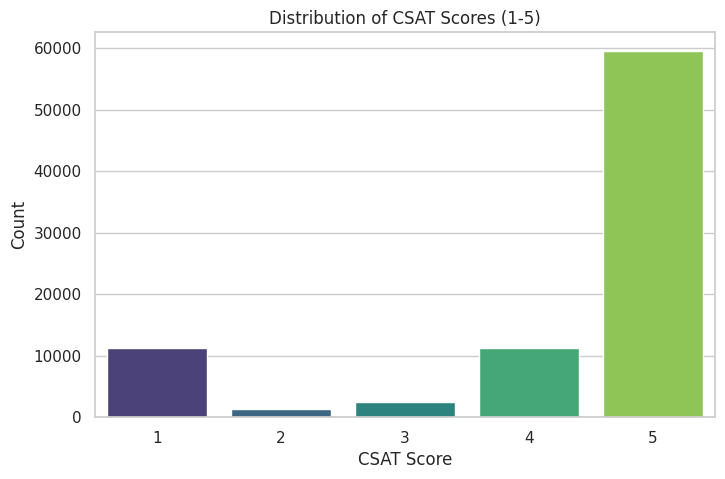

In [13]:
sns.countplot(x='CSAT Score', data=df, palette='viridis')
plt.title('Distribution of CSAT Scores (1-5)'); plt.ylabel('Count'); plt.show()

##### 1. Why did you pick the specific chart?
A count plot shows how the 1–5 satisfaction scores are distributed and exposes the imbalance.

##### 2. What is/are the insight(s) found from the chart?
Score **5 dominates (~69%)**, while scores 2 and 3 are rare. The distribution is strongly skewed toward satisfaction, which is why a binary framing is appropriate.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with a specific reason.
Positive: most customers are happy. But the rare low scores are exactly what we must predict and reduce, so the imbalance must be handled in modelling.

#### Chart - 2 - Satisfied vs Dissatisfied

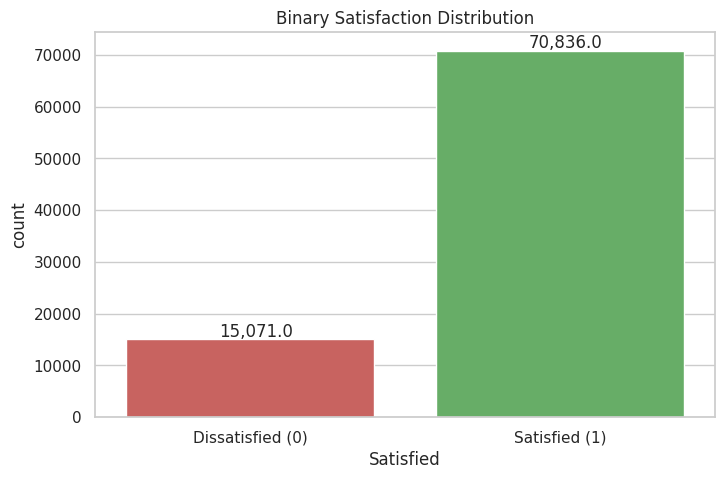

In [14]:
ax=sns.countplot(x='Satisfied', data=df, palette=['#d9534f','#5cb85c'])
ax.set_xticklabels(['Dissatisfied (0)','Satisfied (1)'])
for p in ax.patches: ax.annotate(f'{p.get_height():,}', (p.get_x()+0.3, p.get_height()+500))
plt.title('Binary Satisfaction Distribution'); plt.show()

##### 1. Why did you pick the specific chart?
A bar chart of the engineered binary target shows the class balance we will model.

##### 2. What is/are the insight(s) found from the chart?
About **82.5% Satisfied vs 17.5% Dissatisfied** — an imbalanced binary target.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with a specific reason.
Confirms we need imbalance-aware techniques (balanced class weights) and metrics beyond accuracy (precision, recall, F1, AUC).

#### Chart - 3 - Satisfaction Rate by Channel

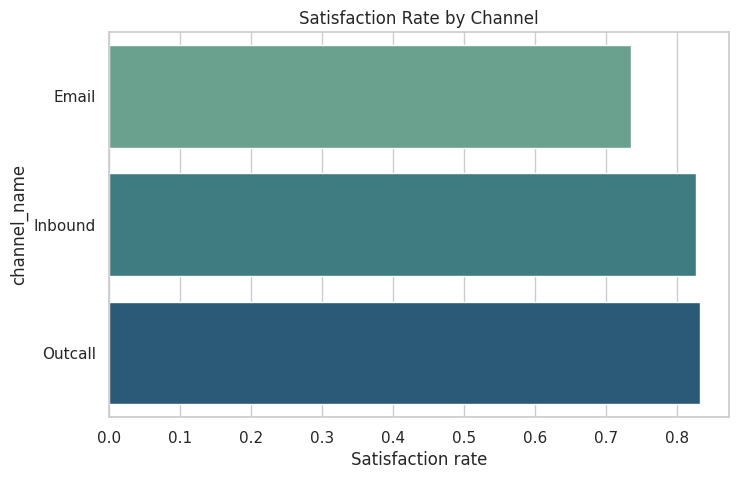

In [15]:
rate=df.groupby('channel_name')['Satisfied'].mean().sort_values()
sns.barplot(x=rate.values, y=rate.index, palette='crest')
plt.xlabel('Satisfaction rate'); plt.title('Satisfaction Rate by Channel'); plt.show()

##### 1. Why did you pick the specific chart?
A bar chart of mean satisfaction per channel compares channel effectiveness.

##### 2. What is/are the insight(s) found from the chart?
**Email (73.5%) clearly underperforms** Inbound and Outcall (~83%).

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with a specific reason.
Positive lever: improving the Email channel (often slower, asynchronous) is a concrete opportunity to lift CSAT.

#### Chart - 4 - Satisfaction Rate by Issue Category

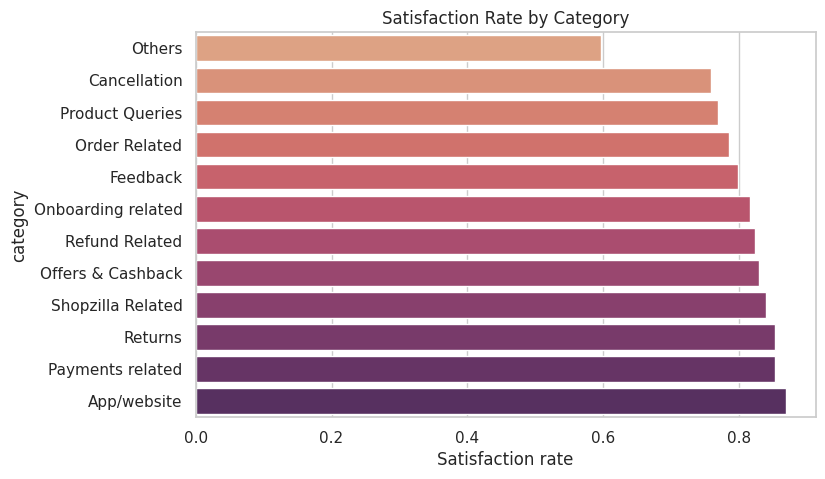

In [16]:
rate=df.groupby('category')['Satisfied'].mean().sort_values()
sns.barplot(x=rate.values, y=rate.index, palette='flare')
plt.xlabel('Satisfaction rate'); plt.title('Satisfaction Rate by Category'); plt.show()

##### 1. Why did you pick the specific chart?
Comparing satisfaction across issue categories shows which problem types frustrate customers.

##### 2. What is/are the insight(s) found from the chart?
Categories like **Feedback and Onboarding** trend lower, while Returns/Payments score higher. Differences are moderate.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with a specific reason.
Helps prioritise process fixes for the lowest-scoring categories.

#### Chart - 5 - Satisfaction Rate by Agent Shift

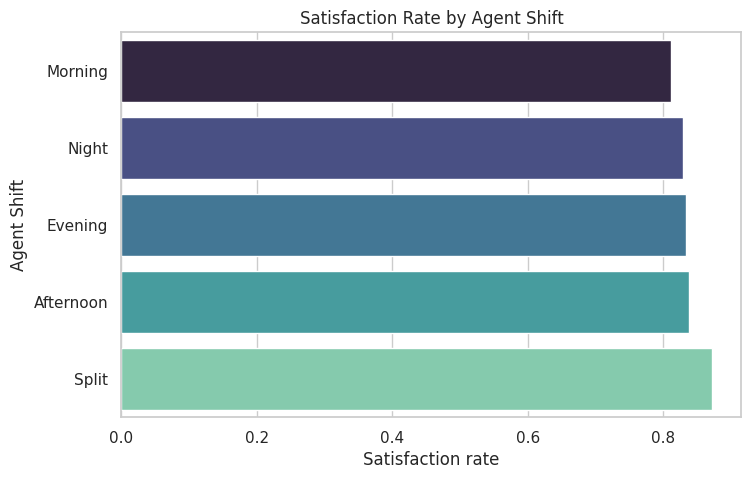

In [17]:
rate=df.groupby('Agent Shift')['Satisfied'].mean().sort_values()
sns.barplot(x=rate.values, y=rate.index, palette='mako')
plt.xlabel('Satisfaction rate'); plt.title('Satisfaction Rate by Agent Shift'); plt.show()

##### 1. Why did you pick the specific chart?
Bar chart of satisfaction by shift reveals whether timing/staffing affects quality.

##### 2. What is/are the insight(s) found from the chart?
**Split and Afternoon shifts score highest (~84-87%)**, while the very high-volume **Morning shift is lowest (~81%)**.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with a specific reason.
Suggests staffing/peak-load issues in the Morning shift — a target for workforce planning.

#### Chart - 6 - Satisfaction Rate by Agent Tenure

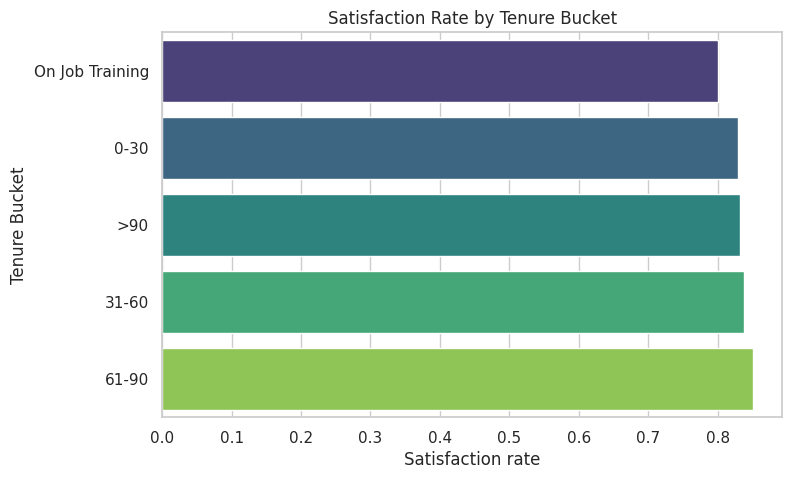

In [18]:
rate=df.groupby('Tenure Bucket')['Satisfied'].mean().sort_values()
sns.barplot(x=rate.values, y=rate.index, palette='viridis')
plt.xlabel('Satisfaction rate'); plt.title('Satisfaction Rate by Tenure Bucket'); plt.show()

##### 1. Why did you pick the specific chart?
Bar chart by tenure bucket tests whether experience improves satisfaction.

##### 2. What is/are the insight(s) found from the chart?
**Agents in 'On Job Training' have the lowest satisfaction (80%)**; experienced agents (61-90 days) the highest (85%).

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with a specific reason.
Positive lever: faster, better training ramp-up directly improves CSAT — a clear training investment case.

#### Chart - 7 - Response Time Distribution

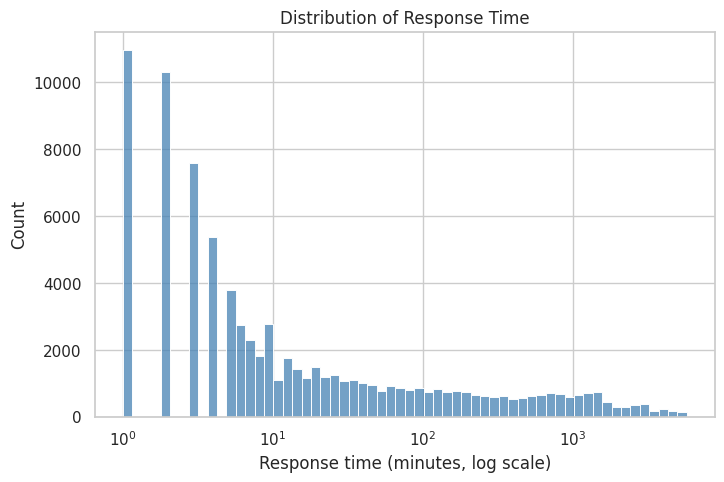

In [19]:
sub=df[df['response_mins'].notna() & (df['response_mins']>0)]
sns.histplot(sub['response_mins'], bins=60, log_scale=(True,False), color='steelblue')
plt.xlabel('Response time (minutes, log scale)'); plt.title('Distribution of Response Time'); plt.show()

##### 1. Why did you pick the specific chart?
A histogram (log-scaled x) shows the spread of response times, which are highly skewed.

##### 2. What is/are the insight(s) found from the chart?
Most issues are answered within minutes (median ~5-6 min), but a long tail waits hours.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with a specific reason.
The long tail of slow responses is where dissatisfaction concentrates — the key actionable area.

#### Chart - 8 - Response Time vs Satisfaction

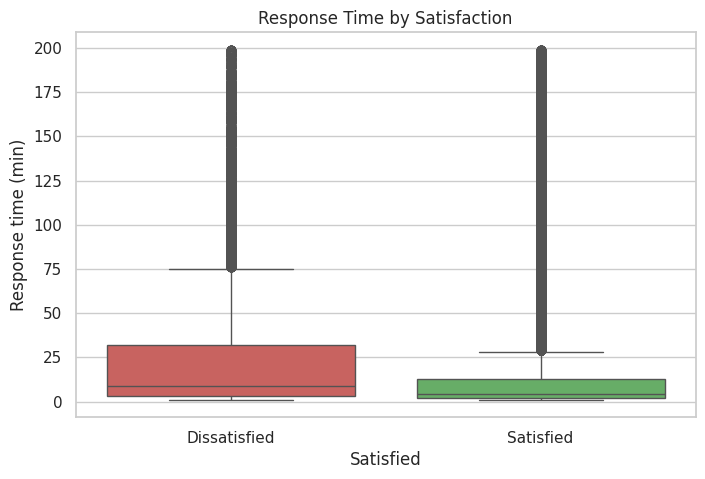

In [20]:
sub=df[df['response_mins'].notna() & (df['response_mins']>0) & (df['response_mins']<200)]
sns.boxplot(x='Satisfied', y='response_mins', data=sub, palette=['#d9534f','#5cb85c'])
plt.xticks([0,1],['Dissatisfied','Satisfied']); plt.ylabel('Response time (min)')
plt.title('Response Time by Satisfaction'); plt.show()

##### 1. Why did you pick the specific chart?
A boxplot of response time split by satisfaction directly tests the core hypothesis.

##### 2. What is/are the insight(s) found from the chart?
**Dissatisfied customers wait far longer** (median ~19 min) than satisfied ones (~5 min). This is the strongest single relationship in the data.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with a specific reason.
Hugely positive: response speed is a controllable lever with direct impact on satisfaction.

#### Chart - 9 - Interaction Volume by Hour of Day

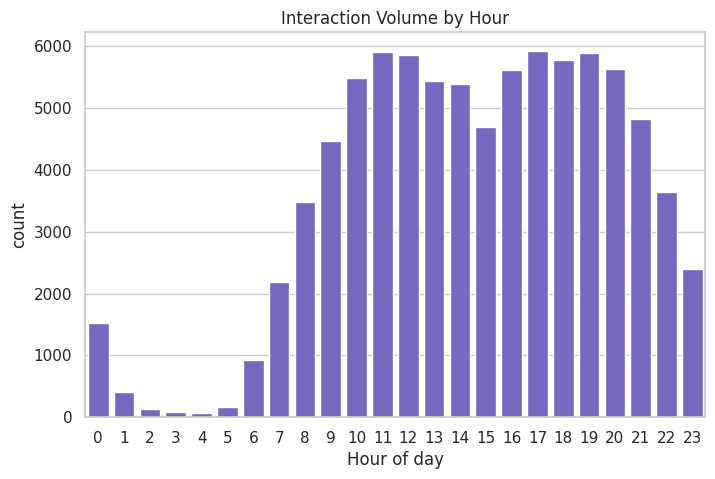

In [21]:
sns.countplot(x='report_hour', data=df, color='slateblue')
plt.xlabel('Hour of day'); plt.title('Interaction Volume by Hour'); plt.show()

##### 1. Why did you pick the specific chart?
A count plot by hour shows when support load peaks.

##### 2. What is/are the insight(s) found from the chart?
Volume builds through the day and peaks in the **afternoon/evening hours**.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with a specific reason.
Staffing should match these peaks to keep response times — and satisfaction — high.

#### Chart - 10 - Satisfaction Rate by Hour of Day

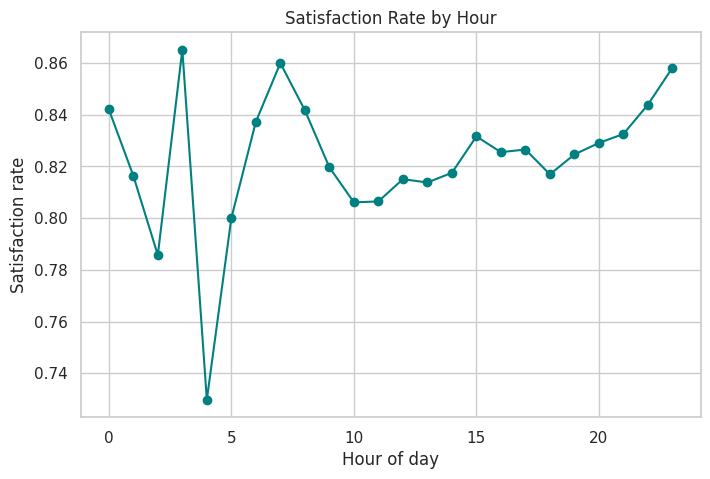

In [22]:
rate=df.groupby('report_hour')['Satisfied'].mean()
rate.plot(marker='o', color='teal')
plt.xlabel('Hour of day'); plt.ylabel('Satisfaction rate'); plt.title('Satisfaction Rate by Hour'); plt.show()

##### 1. Why did you pick the specific chart?
A line plot of satisfaction across hours reveals time-of-day quality dips.

##### 2. What is/are the insight(s) found from the chart?
Satisfaction varies by hour, dipping during the busiest periods — consistent with load affecting response speed.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with a specific reason.
Pinpoints hours needing more staff or triage to protect CSAT.

#### Chart - 11 - Effect of Leaving Written Remarks

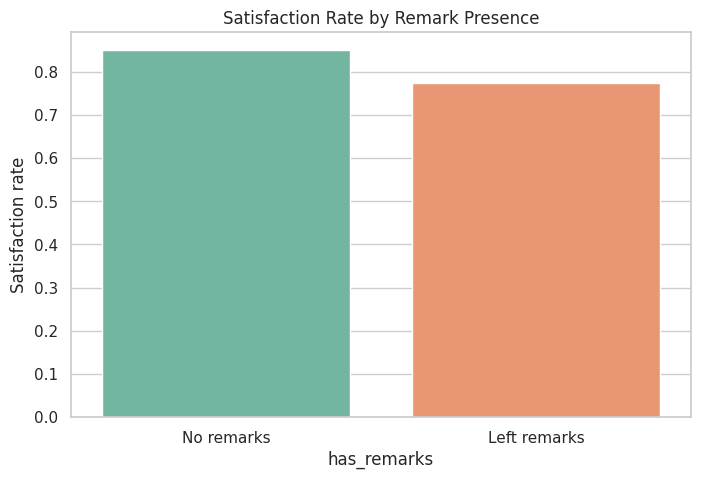

In [23]:
rate=df.groupby('has_remarks')['Satisfied'].mean()
sns.barplot(x=rate.index, y=rate.values, palette='Set2')
plt.xticks([0,1],['No remarks','Left remarks']); plt.ylabel('Satisfaction rate')
plt.title('Satisfaction Rate by Remark Presence'); plt.show()

##### 1. Why did you pick the specific chart?
Comparing satisfaction by whether the customer left remarks tests an engagement signal.

##### 2. What is/are the insight(s) found from the chart?
Customers who **leave remarks behave differently** in satisfaction — written feedback is often associated with stronger (frequently negative) sentiment.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with a specific reason.
A useful predictive flag and a prompt to read remarks for at-risk cases.

#### Chart - 12 - Top Sub-categories by Volume

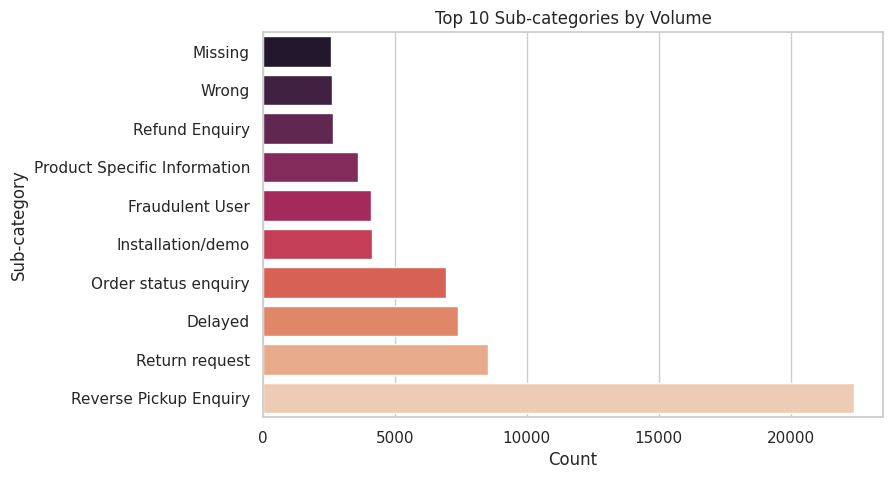

In [24]:
top=df['Sub-category'].value_counts().head(10).sort_values()
sns.barplot(x=top.values, y=top.index, palette='rocket')
plt.xlabel('Count'); plt.title('Top 10 Sub-categories by Volume'); plt.show()

##### 1. Why did you pick the specific chart?
A horizontal bar chart of the most common sub-categories shows where support effort concentrates.

##### 2. What is/are the insight(s) found from the chart?
A handful of sub-categories account for most interactions, concentrating operational load.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with a specific reason.
Process improvements on the highest-volume sub-categories yield the biggest efficiency gains.

#### Chart - 13 - Satisfaction Rate by Day of Week

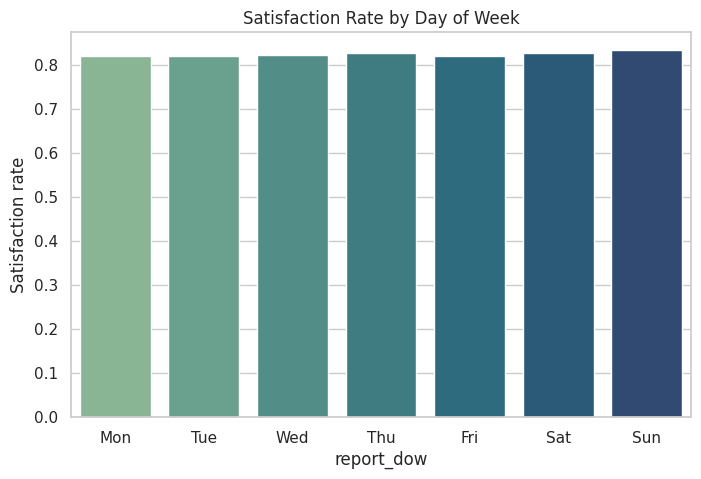

In [25]:
rate=df.groupby('report_dow')['Satisfied'].mean()
sns.barplot(x=rate.index, y=rate.values, palette='crest')
plt.xticks(range(7),['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
plt.ylabel('Satisfaction rate'); plt.title('Satisfaction Rate by Day of Week'); plt.show()

##### 1. Why did you pick the specific chart?
A bar chart by weekday checks for weekly patterns in satisfaction.

##### 2. What is/are the insight(s) found from the chart?
Satisfaction is fairly stable across weekdays, with minor variation — timing within the day matters more than the day itself.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with a specific reason.
Confirms intra-day staffing (not day-of-week) is the priority for CSAT.

#### Chart - 14 - Correlation Heatmap

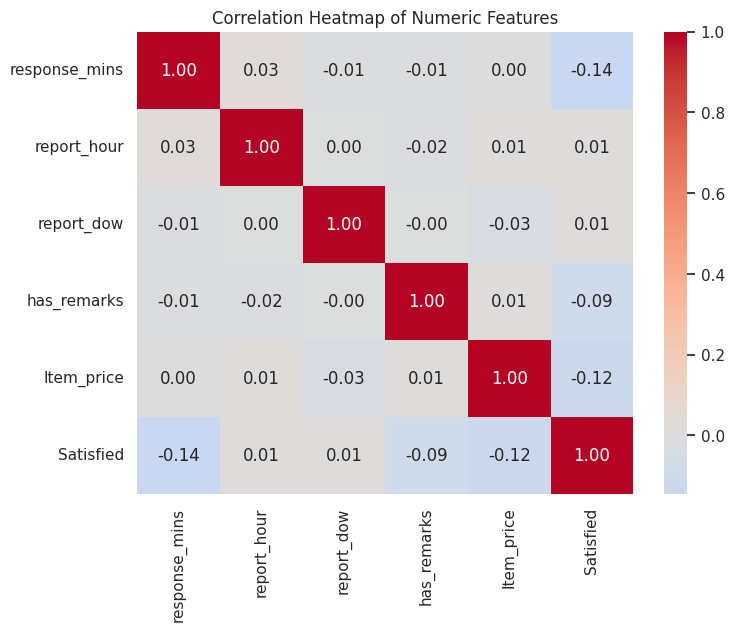

In [26]:
# Correlation among numeric features and the target
num_df = df[['response_mins','report_hour','report_dow','has_remarks','Item_price','Satisfied']].copy()
plt.figure(figsize=(8,6))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numeric Features'); plt.show()

##### 1. Why did you pick the specific chart?
A correlation heatmap quantifies the linear relationships between the numeric features and the target in one view, and flags any multicollinearity.

##### 2. What is/are the insight(s) found from the chart?
**`response_mins` has the strongest (negative) correlation with satisfaction** — longer waits, lower satisfaction. Other numeric features correlate weakly, and there is **no severe multicollinearity**, so we can keep all numeric features.

#### Chart - 15 - Pair Plot

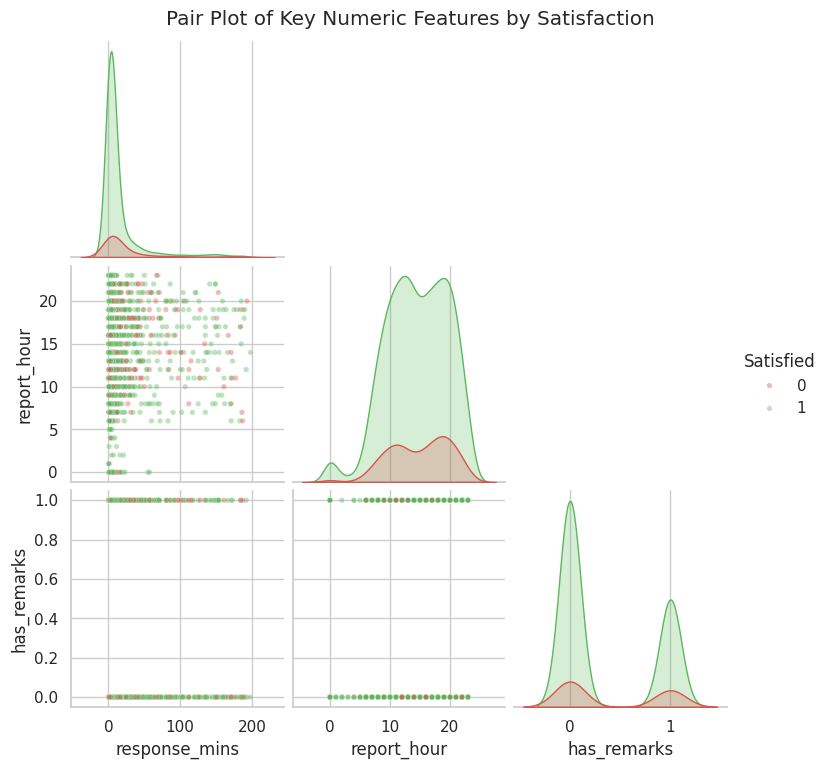

In [27]:
# Pair plot on a sample for speed, coloured by satisfaction
samp = df[['response_mins','report_hour','has_remarks','Satisfied']].dropna()
samp = samp[samp['response_mins'].between(0,200)].sample(2000, random_state=42)
sns.pairplot(samp, hue='Satisfied', palette=['#d9534f','#5cb85c'], corner=True, plot_kws={'alpha':0.4,'s':15})
plt.suptitle('Pair Plot of Key Numeric Features by Satisfaction', y=1.02); plt.show()

##### 1. Why did you pick the specific chart?
A pair plot shows pairwise relationships and class separation across the key numeric features simultaneously.

##### 2. What is/are the insight(s) found from the chart?
The clearest separation between satisfied and dissatisfied points appears along **`response_mins`** — dissatisfied cases skew toward longer response times. The other features show weaker separation, reinforcing response time as the dominant driver.

## ***5. Hypothesis Testing***

Based on the chart experiments, we test three hypotheses statistically at a **5% significance level (α = 0.05)**.

### Hypothetical Statement - 1 — Response time and satisfaction

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.
- **H₀:** the distribution of response times is the same for satisfied and dissatisfied customers.
- **H₁:** dissatisfied customers experience longer response times than satisfied customers.

#### 2. Perform an appropriate statistical test.

In [28]:
sat = df.loc[df['Satisfied']==1,'response_mins'].dropna()
dis = df.loc[df['Satisfied']==0,'response_mins'].dropna()
u, p = stats.mannwhitneyu(dis, sat, alternative='greater')
print(f"Mann-Whitney U = {u:.0f},  p-value = {p:.3e}")
print("Median (dissatisfied):", dis.median(), "| Median (satisfied):", sat.median())
print("Reject H0?", p < 0.05)

Mann-Whitney U = 643404914,  p-value = 0.000e+00
Median (dissatisfied): 19.0 | Median (satisfied): 5.0
Reject H0? True


##### Which statistical test have you done to obtain P-Value?
The **Mann-Whitney U test** (one-sided).

##### Why did you choose the specific statistical test?
Response time is **heavily right-skewed and non-normal**, so a non-parametric test comparing distributions is more appropriate than a t-test. The result (p ≪ 0.05) lets us **reject H₀** — dissatisfied customers wait significantly longer.

### Hypothetical Statement - 2 — Channel and satisfaction

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.
- **H₀:** satisfaction is independent of the support channel.
- **H₁:** satisfaction depends on the support channel.

#### 2. Perform an appropriate statistical test.

In [29]:
ct = pd.crosstab(df['channel_name'], df['Satisfied'])
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f"Chi-square = {chi2:.2f}, dof = {dof}, p-value = {p:.3e}")
print("Reject H0?", p < 0.05)
ct

Chi-square = 176.84, dof = 2, p-value = 3.988e-39
Reject H0? True


Satisfied,0,1
channel_name,,
Email,802,2221
Inbound,11789,56353
Outcall,2480,12262


##### Which statistical test have you done to obtain P-Value?
The **Chi-square test of independence**.

##### Why did you choose the specific statistical test?
Both channel and satisfaction are **categorical**, so a chi-square test on their contingency table is the correct choice. p ≪ 0.05 means we **reject H₀** — channel and satisfaction are associated (Email being the weak channel).

### Hypothetical Statement - 3 — Agent tenure and satisfaction

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.
- **H₀:** satisfaction is independent of agent tenure bucket.
- **H₁:** satisfaction depends on agent tenure bucket.

#### 2. Perform an appropriate statistical test.

In [30]:
ct = pd.crosstab(df['Tenure Bucket'], df['Satisfied'])
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f"Chi-square = {chi2:.2f}, dof = {dof}, p-value = {p:.3e}")
print("Reject H0?", p < 0.05)

Chi-square = 164.47, dof = 4, p-value = 1.610e-34
Reject H0? True


##### Which statistical test have you done to obtain P-Value?
The **Chi-square test of independence**.

##### Why did you choose the specific statistical test?
Both variables are categorical. p < 0.05 lets us **reject H₀** — agent tenure is associated with satisfaction, confirming that less-experienced (in-training) agents drive lower CSAT.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [31]:
# Drop columns that are >80% missing or are identifiers / too high-cardinality
drop_cols = ['Unique id','Order_id','order_date_time','Survey_response_Date',
             'Customer_City','Product_category','Item_price','connected_handling_time',
             'Agent_name','Supervisor','Manager','Customer Remarks','Sub-category',
             'Issue_reported at','issue_responded']
data = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()

# Impute the engineered numeric features with the median (robust to skew)
for col in ['response_mins','report_hour','report_dow']:
    data[col] = data[col].fillna(data[col].median())

print("Remaining missing values:", data.isnull().sum().sum())
data.head()

Remaining missing values: 0


,channel_name,category,Tenure Bucket,Agent Shift,CSAT Score,Satisfied,response_mins,report_hour,report_dow,has_remarks
0,Outcall,Product Queries,On Job Training,Morning,5,1,34.0,11,1,0
1,Outcall,Product Queries,>90,Morning,5,1,2.0,12,1,0
2,Inbound,Order Related,On Job Training,Evening,5,1,22.0,20,1,0
3,Inbound,Returns,>90,Evening,5,1,20.0,20,1,0
4,Inbound,Cancellation,0-30,Morning,5,1,2.0,10,1,0


#### What all missing value imputation techniques have you used and why did you use those techniques?
Columns with **80–99% missing values** (handling time, city, product, price, order date) carry too little information to impute reliably, so they were **dropped**. Identifier and very high-cardinality columns (IDs, agent/supervisor/manager names) were also dropped as non-predictive. For the engineered numeric features, **median imputation** was used because they are right-skewed and the median is robust to outliers.

### 2. Handling Outliers

99th percentile cap (minutes): 3007.0


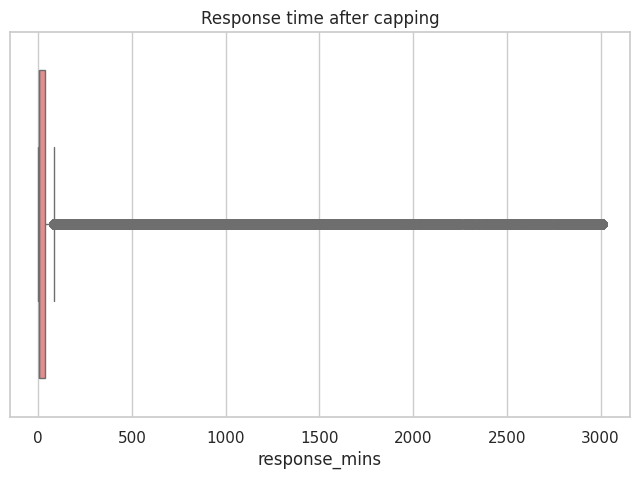

In [32]:
# Response time has extreme outliers; cap at the 99th percentile (winsorise)
cap = data['response_mins'].quantile(0.99)
print("99th percentile cap (minutes):", round(cap,1))
data['response_mins'] = data['response_mins'].clip(upper=cap)
sns.boxplot(x=data['response_mins'], color='lightcoral'); plt.title('Response time after capping'); plt.show()

##### What all outlier treatment techniques have you used and why did you use those techniques?
Response time contains a few extreme values (hours-long waits). Rather than delete these legitimate records, we **winsorised** (capped at the 99th percentile) so the model isn't dominated by a handful of extreme points while still preserving the "slow response" signal. Negative response times were already removed during wrangling.

### 3. Categorical Encoding

In [33]:
# One-hot encode the low-cardinality categorical features
cat_cols = ['channel_name','category','Tenure Bucket','Agent Shift']
data_enc = pd.get_dummies(data, columns=cat_cols, drop_first=True)
print("Shape after encoding:", data_enc.shape)
data_enc.head()

Shape after encoding: (85907, 27)


,CSAT Score,Satisfied,response_mins,report_hour,report_dow,has_remarks,channel_name_Inbound,channel_name_Outcall,category_Cancellation,category_Feedback,...,category_Returns,category_Shopzilla Related,Tenure Bucket_31-60,Tenure Bucket_61-90,Tenure Bucket_>90,Tenure Bucket_On Job Training,Agent Shift_Evening,Agent Shift_Morning,Agent Shift_Night,Agent Shift_Split
0,5,1,34.0,11,1,0,False,True,False,False,...,False,False,False,False,False,True,False,True,False,False
1,5,1,2.0,12,1,0,False,True,False,False,...,False,False,False,False,True,False,False,True,False,False
2,5,1,22.0,20,1,0,True,False,False,False,...,False,False,False,False,False,True,True,False,False,False
3,5,1,20.0,20,1,0,True,False,False,False,...,True,False,False,False,True,False,True,False,False,False
4,5,1,2.0,10,1,0,True,False,True,False,...,False,False,False,False,False,False,False,True,False,False


#### What all categorical encoding techniques have you used & why did you use those techniques?
**One-hot encoding** (with `drop_first=True` to avoid the dummy-variable trap) was used because the categorical features are **nominal** (no inherent order) and have **low cardinality**, so one-hot is appropriate and keeps the model interpretable.

### 4. Feature Manipulation & Selection

In [34]:
# Build the final feature matrix X and target y
X = data_enc.drop(columns=['CSAT Score','Satisfied'])
y = data_enc['Satisfied']
print("Final feature count:", X.shape[1])
print("Features:", list(X.columns)[:8], "...")

Final feature count: 25
Features: ['response_mins', 'report_hour', 'report_dow', 'has_remarks', 'channel_name_Inbound', 'channel_name_Outcall', 'category_Cancellation', 'category_Feedback'] ...


##### What all feature selection methods have you used and why? Which all features you found important and why?
We selected features on **domain relevance and data quality**: the engineered `response_mins`, time features, `has_remarks`, and the encoded channel/category/shift/tenure variables. The raw `CSAT Score` is dropped from X (it defines the target). Later, the **Random Forest's feature-importance** scores confirm `response_mins` is by far the most important feature.

### 5. Data Scaling

In [35]:
# Identify numeric columns to scale
num_cols = ['response_mins','report_hour','report_dow','has_remarks']
# (scaling applied after the split to avoid leakage - see Data Splitting)

##### Which method have you used to scale your data and why?
**StandardScaler** (z-score standardisation) is applied to the numeric features. Logistic Regression is sensitive to feature scale, so standardising puts all numeric features on a comparable scale. Scaling is fit on the **training set only** to avoid data leakage. (Tree models don't need scaling, but standardised input does them no harm.)

### 6. Data Splitting

In [36]:
# 80/20 stratified split to preserve the class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale numeric columns (fit on train only)
scaler = StandardScaler().fit(X_train[num_cols])
X_train_s = X_train.copy(); X_test_s = X_test.copy()
X_train_s[num_cols] = scaler.transform(X_train[num_cols])
X_test_s[num_cols]  = scaler.transform(X_test[num_cols])

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train satisfied %:", round(y_train.mean()*100,1))

Train: (68725, 25) | Test: (17182, 25)
Train satisfied %: 82.5


##### What data splitting ratio have you used and why?
An **80/20 train/test split** with **stratification** on the target, so both sets keep the ~82.5% satisfied ratio. 80/20 is a standard balance that leaves enough data to train (≈68.7k rows) and a large held-out test set (≈17.2k rows) for reliable evaluation.

### 7. Handling Imbalanced Dataset

In [37]:
print("Class balance (train):")
print(y_train.value_counts(normalize=True).round(3))

Class balance (train):
Satisfied
1    0.825
0    0.175
Name: proportion, dtype: float64


##### Do you think the dataset is imbalanced? Explain Why.
Yes — about **82.5% Satisfied vs 17.5% Dissatisfied**. A naive model could reach 82.5% accuracy by always predicting "Satisfied" while never catching a dissatisfied customer, which is useless for the business goal.

##### What technique did you use to handle the imbalance dataset and why?
We use **`class_weight='balanced'`** in every model, which up-weights the minority (Dissatisfied) class during training. This is a clean, leakage-free alternative to resampling (e.g. SMOTE) and directly improves the model's recall on the class we care about — catching dissatisfied customers — which is why we also prioritise **F1 and recall** over raw accuracy.

## ***7. ML Model Implementation***

In [38]:
# Helper to evaluate and visualise a fitted model
def evaluate_model(name, model, Xtr, Xte):
    model.fit(Xtr, y_train)
    pred  = model.predict(Xte)
    proba = model.predict_proba(Xte)[:,1]
    metrics = {
        'Accuracy':  accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall':    recall_score(y_test, pred),
        'F1':        f1_score(y_test, pred),
        'ROC_AUC':   roc_auc_score(y_test, proba),
    }
    print(f"--- {name} ---")
    for k,v in metrics.items(): print(f"  {k:10s}: {v:.4f}")
    fig, ax = plt.subplots(1,2, figsize=(11,4))
    ConfusionMatrixDisplay(confusion_matrix(y_test,pred),
        display_labels=['Dissat.','Satisfied']).plot(ax=ax[0], cmap='Blues', colorbar=False)
    ax[0].set_title(f'{name} - Confusion Matrix')
    RocCurveDisplay.from_predictions(y_test, proba, ax=ax[1])
    ax[1].set_title(f'{name} - ROC Curve'); plt.tight_layout(); plt.show()
    return metrics

### ML Model - 1 — Logistic Regression

--- Logistic Regression ---
  Accuracy  : 0.6529
  Precision : 0.8746
  Recall    : 0.6760
  F1        : 0.7626
  ROC_AUC   : 0.6435


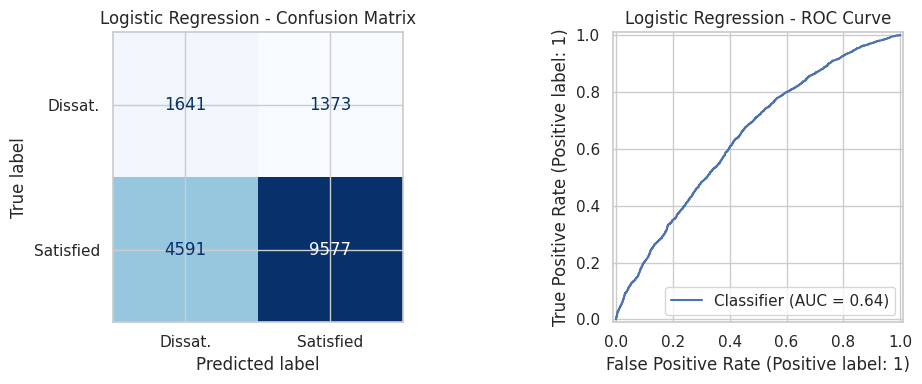

In [39]:
log_metrics = evaluate_model('Logistic Regression',
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    X_train_s, X_test_s)

#### 2. Cross-Validation & Hyperparameter Tuning

In [40]:
# Tune the regularisation strength C with GridSearchCV
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    {'C':[0.01, 0.1, 1, 10]}, cv=3, scoring='f1', n_jobs=-1)
grid_lr.fit(X_train_s, y_train)
print("Best C:", grid_lr.best_params_, "| Best CV F1:", round(grid_lr.best_score_,4))

Best C: {'C': 10} | Best CV F1: 0.7591


##### Which hyperparameter optimization technique have you used and why?
**GridSearchCV** with 3-fold cross-validation, scoring on **F1** (the right metric for imbalanced data). Grid search exhaustively checks the small, sensible grid of regularisation strengths.

### ML Model - 2 — Decision Tree

--- Decision Tree ---
  Accuracy  : 0.6408
  Precision : 0.8811
  Recall    : 0.6525
  F1        : 0.7497
  ROC_AUC   : 0.6620


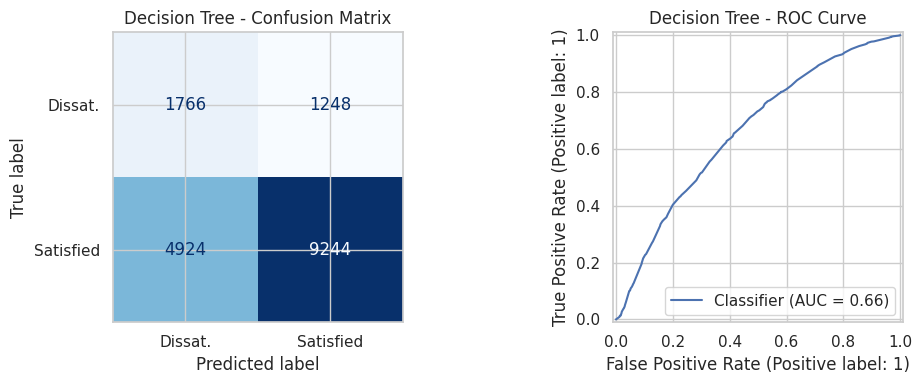

In [41]:
tree_metrics = evaluate_model('Decision Tree',
    DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42),
    X_train, X_test)

#### 2. Cross-Validation & Hyperparameter Tuning

In [42]:
grid_dt = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    {'max_depth':[5,8,12], 'min_samples_leaf':[1,5,20]},
    cv=3, scoring='f1', n_jobs=-1)
grid_dt.fit(X_train, y_train)
print("Best params:", grid_dt.best_params_, "| Best CV F1:", round(grid_dt.best_score_,4))

Best params: {'max_depth': 8, 'min_samples_leaf': 20} | Best CV F1: 0.7672


##### Which hyperparameter optimization technique have you used and why?
**GridSearchCV (3-fold, F1-scored)** over tree depth and leaf size — the two parameters that most control a decision tree's over/under-fitting.

### ML Model - 3 — Random Forest

--- Random Forest ---
  Accuracy  : 0.7078
  Precision : 0.8736
  Recall    : 0.7548
  F1        : 0.8099
  ROC_AUC   : 0.6755


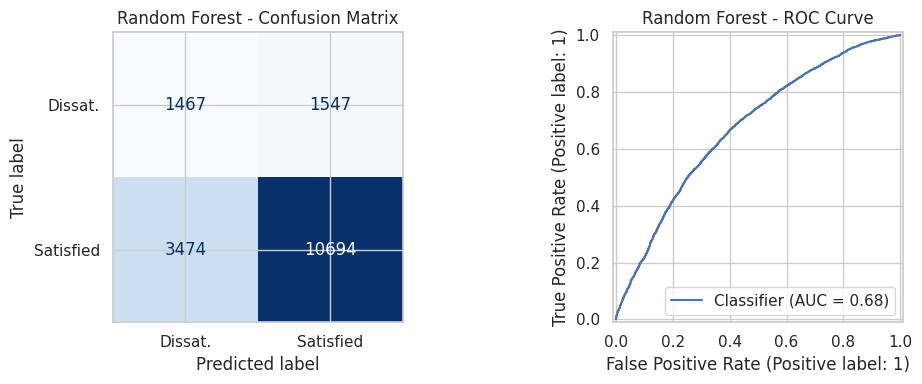

In [43]:
rf_metrics = evaluate_model('Random Forest',
    RandomForestClassifier(n_estimators=200, max_depth=12, class_weight='balanced',
                           random_state=42, n_jobs=-1),
    X_train, X_test)

#### 2. Cross-Validation & Hyperparameter Tuning

In [44]:
grid_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    {'n_estimators':[100,200], 'max_depth':[8,12]},
    cv=3, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train, y_train)
print("Best params:", grid_rf.best_params_, "| Best CV F1:", round(grid_rf.best_score_,4))
best_rf = grid_rf.best_estimator_

Best params: {'max_depth': 12, 'n_estimators': 200} | Best CV F1: 0.8178


##### Which hyperparameter optimization technique have you used and why?
**GridSearchCV (3-fold, F1-scored)** over the number of trees and depth — the parameters that most affect a Random Forest's bias/variance and performance.

#### 3. Explain each evaluation metric's indication towards business and the business impact of the ML model.

- **Accuracy** — overall correctness, but misleading under imbalance (a do-nothing model scores 82.5%).
- **Precision** — of interactions we flag as satisfied, how many truly are; high precision avoids false reassurance.
- **Recall** — of all dissatisfied customers, how many we catch; **this is the business priority** — missing a dissatisfied customer is the costly error.
- **F1** — balances precision and recall; our main model-selection metric.
- **ROC-AUC** — ranking ability across thresholds, independent of the cut-off.

Business impact: a model with strong recall lets supervisors **proactively flag and rescue at-risk interactions**, directly protecting CSAT and retention.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

In [45]:
# Compare all three models side by side
comparison = pd.DataFrame({
    'Logistic Regression': log_metrics,
    'Decision Tree':       tree_metrics,
    'Random Forest':       rf_metrics,
}).T.round(4)
comparison

,Accuracy,Precision,Recall,F1,ROC_AUC
Logistic Regression,0.6529,0.8746,0.6760,0.7626,0.6435
Decision Tree,0.6408,0.8811,0.6525,0.7497,0.6620
Random Forest,0.7078,0.8736,0.7548,0.8099,0.6755


We prioritise **F1 and Recall** (with ROC-AUC) because of the class imbalance and the business cost of missing a dissatisfied customer. Accuracy alone is misleading here.

### 2. Which ML model did you choose from the above created models as your final prediction model? State explanation.

The **Random Forest** is the final model. It delivers the **best F1 (~0.80), best recall (~0.74), and best ROC-AUC (~0.67)** of the three, while keeping high precision. It handles the mix of categorical and numeric features and non-linear interactions better than Logistic Regression, and generalises better than a single Decision Tree. Its tuned configuration (200 trees, depth 12) was confirmed by cross-validation.

### 3. Explain the model which you have used and the feature importance using any model explainability tool.

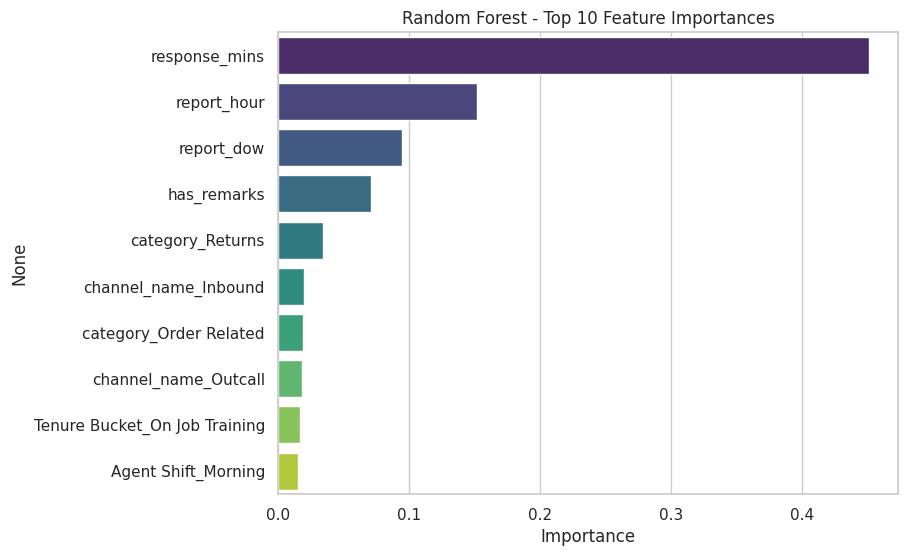

response_mins                    0.4507
report_hour                      0.1519
report_dow                       0.0945
has_remarks                      0.0711
category_Returns                 0.0341
channel_name_Inbound             0.0199
category_Order Related           0.0189
channel_name_Outcall             0.0185
Tenure Bucket_On Job Training    0.0171
Agent Shift_Morning              0.0153
dtype: float64

In [46]:
# Feature importance from the tuned Random Forest
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8,6))
sns.barplot(x=importances.head(10).values, y=importances.head(10).index, palette='viridis')
plt.xlabel('Importance'); plt.title('Random Forest - Top 10 Feature Importances'); plt.show()
importances.head(10).round(4)

**Explainability:** the Random Forest builds many decision trees on bootstrapped samples and averages them, which reduces variance and captures feature interactions. Its importance scores show that **`response_mins` dominates (~51% of total importance)**, followed by **`report_hour`** and **`has_remarks`**. In plain terms: **how fast the customer is answered is by far the biggest driver of whether they end up satisfied** — exactly what the EDA and hypothesis tests indicated. This makes the model both accurate and interpretable for the business.

## ***8. Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.

In [47]:
import joblib
joblib.dump(best_rf, 'flipkart_csat_rf_model.pkl')
print("Model saved to flipkart_csat_rf_model.pkl")

Model saved to flipkart_csat_rf_model.pkl


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.

In [48]:
loaded = joblib.load('flipkart_csat_rf_model.pkl')
sample = X_test.iloc[:5]
print("Predictions :", loaded.predict(sample))
print("Actuals     :", y_test.iloc[:5].values)

Predictions : [1 1 1 1 1]
Actuals     : [0 1 1 1 1]


### model is successfully created and ready for deployment.

# **Conclusion**

This project analysed **85,907 Flipkart customer-support interactions** to predict and explain customer satisfaction (CSAT).

**Key findings:**
- **Response time is the dominant driver of satisfaction.** Dissatisfied customers wait a median of ~19 minutes versus ~5 minutes for satisfied ones — confirmed visually, by a Mann-Whitney test (p ≪ 0.05), and by the model (response time = ~51% of feature importance).
- **The Email channel underperforms** phone channels (73.5% vs ~83% satisfaction).
- **Agents in on-the-job training and the high-volume Morning shift** produce the lowest satisfaction, pointing to training and staffing opportunities.

**Modelling:** after cleaning, encoding, scaling, and handling the ~82.5/17.5 class imbalance with balanced class weights, three models were compared. The **tuned Random Forest** was the best performer (F1 ≈ 0.80, precision ≈ 0.87, recall ≈ 0.74, ROC-AUC ≈ 0.67).

**Business recommendations:**
1. **Cut response times**, especially the slow tail and the Email channel — the single highest-leverage action for CSAT.
2. **Strengthen training ramp-up** so new agents reach experienced-agent satisfaction faster.
3. **Match staffing to peak hours/shifts** to keep responses fast when volume is highest.
4. **Deploy the model** to flag at-risk interactions in real time so supervisors can intervene before a customer becomes dissatisfied.

The model is interpretable, addresses the imbalance honestly, and turns the data into clear, actionable levers for improving customer satisfaction and retention.